In [49]:
import numpy as np
import matplotlib.pyplot as plt

## Esercizio 2: Diffusione 2D asimmetrica

Generare una distribuzione random di $\varphi$ tale che 
$$p(\varphi) = \frac{1}{4} \sin{ \frac{ \varphi}{2}}$$

utilizzando il metodo della cumulativa.

Modificare lo script dell'esercizio 1 in modo da considerare accanto alla diffusione simmetrica, una diffusione asimmetrica data dalla formula precedente e produrre un grafico 2D delle posizioni di 5 random walker per 1000 passi.

### Calcolo dei valori distribuiti secondo la funzione di distribuzione attraverso il **Metodo dell'Inversa della Cumulativa**

La cumulativa è data da:
$$ C_{p(\varphi)}= \frac{1}{4}\int_0^\varphi \sin( \frac{ \varphi}{2}) d\varphi \; \Rightarrow \frac{1}{2} \int_0^{2\varphi} \sin(t) dt = \frac{1}{2} (1 - \cos(\frac{\varphi}{2}))$$

$$ \Rightarrow C_{p(\varphi)} = \frac{1}{2} (1 - \cos(\frac{\varphi}{2}))$$

da cui l'inversa, definito $C_{p(\varphi)} \stackrel{.}{=} y$:
$$ C^{-1}_{p(y)} = \varphi = 2\arccos(1 - 2y) \qquad \text{con} \quad y \in [0,1]$$

In [50]:
#Distribuzione di probabilità asimmetrica
def p_as(phi):
    return np.sin(phi/2)/4

#funzione cumulativa
def cum_p(phi):
    return 1/2*(1-np.cos(phi/2))

#inversa cumulativa
def invcum_p(y):
    return 2*np.arccos(1-2*y)

#distribuzione di probabilità simmetrica (uniforme)
def p_sim(phi):
    N=len(phi)
    return np.random.uniform(low=0, high=2*np.pi, size=N)


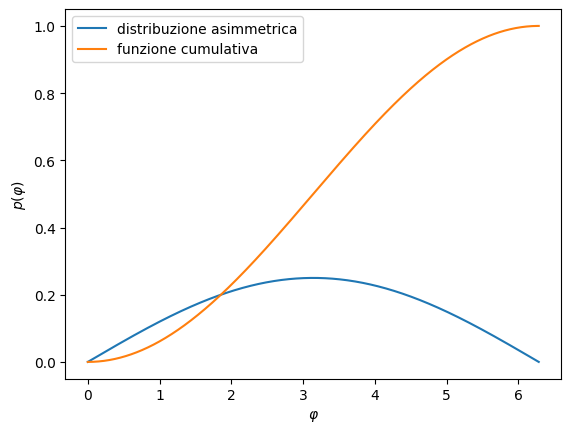

In [51]:
pp=np.linspace(0, 2*np.pi, 1000)
plt.plot(pp, p_as(pp), label='distribuzione asimmetrica')
plt.plot(pp, cum_p(pp), label='funzione cumulativa')
plt.xlabel(r'$\varphi$')
plt.ylabel(r'$p(\varphi)$')
plt.legend()
plt.show()

applicando la funzione $C^{-1}_{p(y)}$ a valori random uniformemente distribuiti nell'intervallo $[0,1]$, si ottengono valori nell'intervallo $[0, 2\pi]$ distribuiti secondo la distribuzione di probabilità $p(\varphi)$.

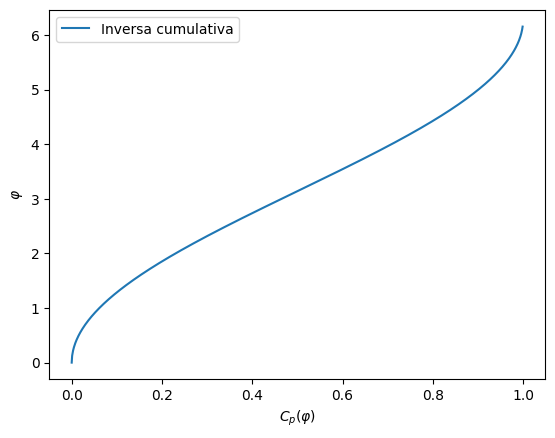

In [52]:
#grafico inversa cumulativa
yy=np.arange(0,1,0.001)
xx1=invcum_p(yy)

plt.plot(yy, xx1, label='Inversa cumulativa')
plt.xlabel(r'$C_p(\varphi)$')
plt.ylabel(r'$\varphi$')
plt.legend()

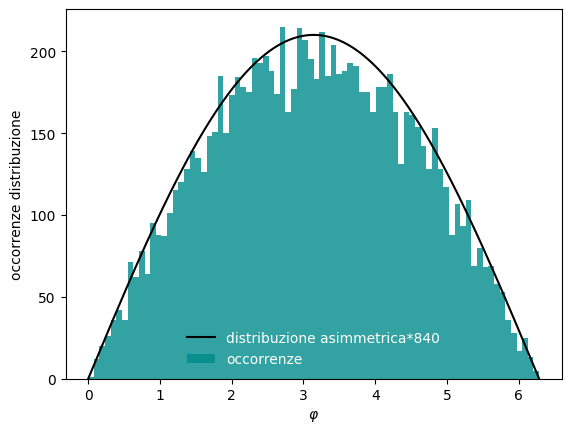

In [53]:
# Uso il metodo della cumulativa per trovare le occorrenze della distribuzione
# genero 10000 valori random casuali per yi in [0,1]
yc=np.random.random(int(1e4))
xc=invcum_p(yc)

#verifico i valori trovati confrontando la distribuzione con l'istogramma delle occorrenze
fig, ax = plt.subplots()
ax.plot(pp, p_as(pp)*840, label='distribuzione asimmetrica*840', color='black')
n, bins, p=ax.hist(xc, bins=80, range=(0,2*np.pi), color='darkcyan', alpha=0.8, label='occorrenze')
ax.set_xlabel(r'$\varphi$', )
ax.set_ylabel('occorrenze distribuzione')
ax.legend(frameon=False, labelcolor='white')

### Implementazione del Random Walk 2D attraverso la distribuzione asimmetrica data

In [54]:
def rnd_walk2D(start, step, n, distr, control):
    '''
    rnd_walk2D(start, step, n, nrwn, distr): funzione che simula un random walk 2D secondo una certa ditribuzione

    start  : posizione di partenza
    step   : passo random walk (modulo del vettore)
    n      : numero di passi
    distr  : inversa della cumulativa della distribuzione di probabilità che regola il random walk
    control: variabile che direziona il fenomeno artificialmente

    reuturn np.array([deltax, deltay]): array con spostamento rispetto alla posizione di partenza per i due assi
    '''

    deltax=np.empty(0) #array con spostamento lungo asse x
    deltay=np.empty(0) #array con spostamento lungo asse y
    movex, movey=start[0], start[1]

    #calcolo valori distribuiti secondo la distribuzione indicata attraverso il metodo dell'inversa della cumulativa
    yc=np.random.random(n)
    var_phi=distr(yc)

    #implementazione del random-walk
    for c in var_phi:
        x_step= step*np.cos(c) + control[0]
        y_step= step*np.sin(c) + control[1]
        movex= movex + x_step
        movey= movey + y_step
        deltax=np.append(deltax, movex)
        deltay=np.append(deltay, movey)

    return np.array([deltax,deltay])

def rnd_ws(start, step, n, nwr, distr, control):
    '''
    rnd_ws(start, step,n,nrw): funzione che simula il moto di un certo numero di random walkers
    start  : vettore posizione iniziale
    step   : passo random walk
    nwr    : numero di random walkers
    n      : numero di passi
    distr  : inversa della cumulativa della distribuzione di probabilità che regola il random walk
    control: variabile che direziona il fenomeno artificialmente

    return rws: array di random walks, in cui ciascun elemento contiene lo spostamento lungo x e y 
    '''
    t=np.full(n,0)
    rws=np.array([np.array([t,t]) for x in range(nwr)])
    for i in range(nwr):
        rw= rnd_walk2D(start ,step, n, distr, control)
        rws[i,0]=rw[0]
        rws[i,1]=rw[1]
    return rws

In [55]:
# calcolo random walks di 5 random walkers secondo la distribuzione data
n_passi=1000
passo=1
sf=np.array([0,0])
xx=np.arange(0,n_passi,1)
pstart=np.array([0,0])
rw_pa=rnd_ws(pstart, passo, n_passi, 5, invcum_p, sf)

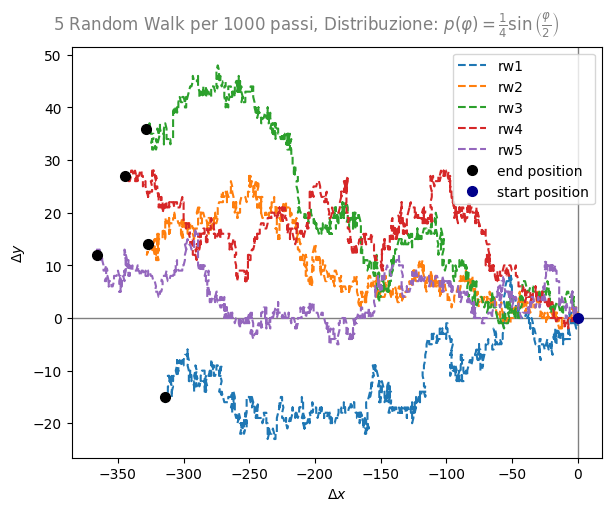

In [56]:
# grafico 2D delle posizioni di 5 random walker per 1000 passi

fig1, ax=plt.subplots(figsize=(6,5), layout='constrained')

plt.suptitle(r'5 Random Walk per 1000 passi, Distribuzione: $ p(\varphi)= \frac{1}{4} \sin \left( \frac{\varphi}{2} \right)$', color = 'grey')
count=1
mark=''
ax.axhline(0, color='grey', linewidth=1)
ax.axvline(0, color='grey', linewidth=1)
for i in rw_pa:
    if(count==5):
        mark='end position'
    ax.plot(i[0], i[1], '--', label='rw{:d}'.format(count))
    ax.plot(i[0][-1], i[1][-1],'o', markersize=7,label=mark, color='black')
    count +=1
ax.plot(pstart[0], pstart[1], 'o', markersize=7, label='start position', color='darkblue')
ax.set_xlabel(r'$\Delta x$')
ax.set_ylabel(r'$\Delta y$')
ax.legend()

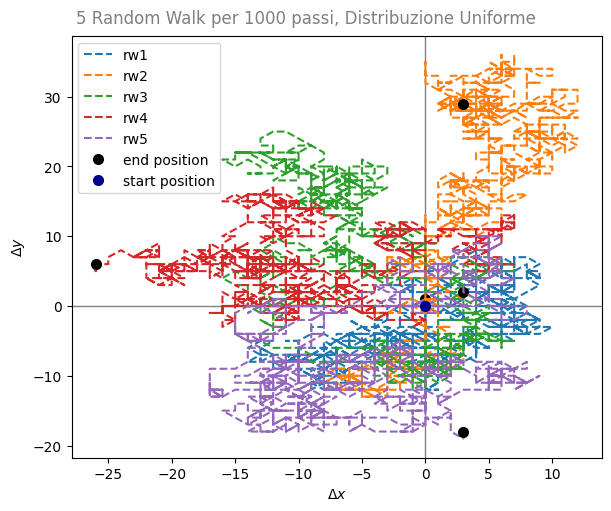

In [57]:
#Random Walk a distribuzione simmetrica
rw_ps=rnd_ws(pstart, passo, n_passi, 5, p_sim, sf)

fig1, ax=plt.subplots(figsize=(6,5), layout='constrained')

plt.suptitle('5 Random Walk per 1000 passi, Distribuzione Uniforme', color = 'grey')
count=1
mark=''
ax.axhline(0, color='grey', linewidth=1)
ax.axvline(0, color='grey', linewidth=1)
for i in rw_ps:
    if(count==5):
        mark='end position'
    ax.plot(i[0], i[1], '--', label='rw{:d}'.format(count))
    ax.plot(i[0][-1], i[1][-1],'o', markersize=7,label=mark, color='black')
    count +=1
ax.plot(pstart[0], pstart[1], 'o', markersize=7, label='start position', color='darkblue')
ax.set_xlabel(r'$\Delta x$')
ax.set_ylabel(r'$\Delta y$')
ax.legend()

## Esercizio 2a: Diffusione 2D asimmetrica (2.0)

Aggiungere una funzione analoga a quella simmetrica ma aggiungendo ad ogni passo un contributo costante e positivo $s_f$ lungo l'asse $x$ e invece di stabilire a priori il numero di passi, arrestare il processo quando la coordinata $x$ supera un valore prestabilito ($ \sim s X 200$).

Produrre un grafico 2D delle posizioni di 5 random walker per la diffusione regolata dalla distribuzione appena definita per:
- $s_f = 0.1 s \;$;
- $s_f=0.01 s \;$.

In [58]:
def sel_n(s, c, x):
    '''
    sel_n(s,n,c): funzione che seleziona il numero di passi di un random walk in modo che la coordinata c < s*n
    s: passo
    x: limite per la coordinata c --> m(c)<s*x
    c: coordinata di riferimento

    restituisce un array contenente: la coordinata c di riferimento, il limite per la coordinata c
    '''
    return [c, s*x]

def rnd_walk2D2(start, step, finish, distr, control):
    '''
    rnd_walk2D(start, step, n, nrwn, distr): funzione che simula un random walk 2D secondo una certa ditribuzione

    start  : posizione di partenza
    step   : passo random walk (modulo del vettore)
    finish : legge che seleziona il numero di passi
    distr  : inversa della cumulativa della distribuzione di probabilità che regola il random walk
    control: variabile che direziona il fenomeno artificialmente

    reuturn deltar: array con spostamento rispetto alla posizione di partenza per i due assi
    '''

    deltax=np.empty(0)
    deltay=np.empty(0) #array con spostamento lungo i due assi
    movex, movey=start[0], start[1]

    x_ref= np.array([movex, start[0], control[0]])
    y_ref=np.array([movey, start[1], control[1]])
    rif_c={'x':x_ref, 'y': y_ref}
    
    #seleziono la coordinata 
    c='x'
    if(type(finish[0])==str):
        if(finish[0] =='y'): 
            c='y'
    else:
        print('Selezionare una coordinata valida!')
        return 0
    
    c_rif=rif_c[c]

    #implementazione del random-walk
    while(np.abs(c_rif[0])<=np.abs(finish[1]-c_rif[1])):
        # estraggo l'occorrenza xc secondo la distribuzione
        yc=np.random.random()
        xc=distr(yc)
        x_step= step*np.cos(xc) + control[0]
        y_step= step*np.sin(xc) + control[1]
        st=np.array([x_step,y_step])
        rif_c['x'][0]= rif_c['x'][0] + st[0]
        rif_c['y'][0]= rif_c['y'][0] + st[1]
        deltax=np.append(deltax, rif_c['x'][0])
        deltay=np.append(deltay, rif_c['y'][0])

    return deltax, deltay

def rnd_ws2(start, step, finish, nwr, distr, control):
    '''
    rnd_ws(start, step, finish, nrw, disrt, control): funzione che simula il moto di un cetro numero di random walkers

    start  : vettore posizione iniziale
    step   : passo random walk
    finish : legge che seleziona il numero di passi
    nwr    : numero di random walkers
    distr  : inversa della cumulativa della distribuzione di probabilità che regola il random walk
    control: variabile che direziona il fenomeno artificialmente

    return t1,t2 : array di random walks,in cui ciascun elemento contiene lo spostamento lungo x e y (divisi dallo 0)
    '''
    t1=np.empty(0)
    t2=np.empty(0)
    for i in range(nwr): 
        rw= rnd_walk2D2(start,step, finish, distr, control)
        t1=np.append(t1, rw[0])
        t1=np.append(t1,0)
        t2=np.append(t2, rw[1])
        t2=np.append(t2, 0)
    return t1,t2

In [59]:
limx=sel_n(passo, 'x', 200)

#sf=0.1s
control1=np.array([0.1*passo, 0])
rw_pa_dir1=rnd_ws2(pstart, passo, limx, 5, invcum_p, control1)
print(len(rw_pa_dir1[0]), len(rw_pa_dir1[1]))
#print(rw_pa_dir1[0])

#estraggo gli indici 0
d1x=np.where(rw_pa_dir1[0]==0)[0]
print(d1x)
s1x=np.zeros(1)
s1x=np.append(0,d1x[:-1])
print(s1x)

#sf=0.01s
control2=np.array([0.01*passo, 0])
rw_pa_dir2=rnd_ws2(pstart, passo, limx,5, invcum_p, control2)
print(len(rw_pa_dir2[0]), len(rw_pa_dir2[1]))
#print(rw_pa_dir2[1])

#estraggo gli indici 0
d2x=np.where(rw_pa_dir2[0]==0)[0]
#print(d1x)
s2x=np.zeros(1)
s2x=np.append(0,d2x[:-1])
#print(s1x)

#ora posso printare i grafici in base agli indici

4608 4608
[ 894 1872 2868 3756 4607]
[   0  894 1872 2868 3756]
3092 3092


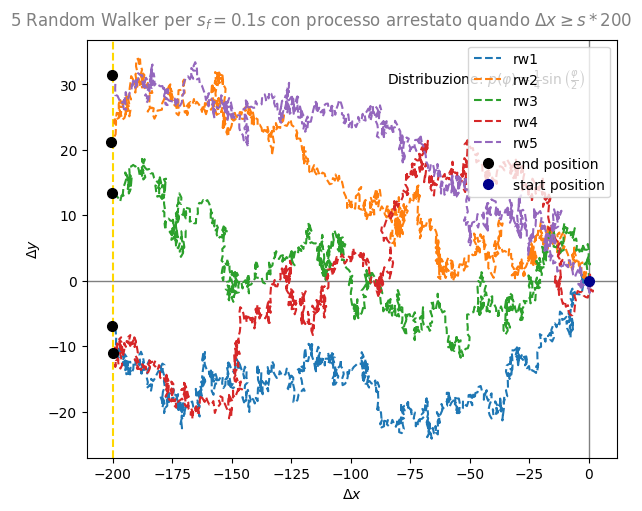

In [60]:
#grafico 5 random walker per sf=0.1, sf=0.01 con processo arrestato quando n = s*200

fig2, ax=plt.subplots(figsize=(6,5), layout='constrained')

plt.suptitle(r'5 Random Walker per $s_f = 0.1 s$ con processo arrestato quando $ \Delta x \geq s*200$', color = 'grey')
count=1
mark=''
ax.axhline(0, color='grey', linewidth=1)
ax.axvline(0, color='grey', linewidth=1)
ax.axvline(-200, color='gold', linestyle='--')
for j,k in zip(s1x, d1x):
    if(count==5):
        mark='end position'
    ax.plot(rw_pa_dir1[0][j:k], rw_pa_dir1[1][j:k], '--', label='rw{:d}'.format(count))
    ax.plot(rw_pa_dir1[0][j:k][-1], rw_pa_dir1[1][j:k][-1],'o', markersize=7,label=mark, color='black')
    count +=1
ax.text(-85,30, r'Distribuzione: $ p(\varphi)= \frac{1}{4} \sin \left( \frac{\varphi}{2} \right)$')
ax.plot(pstart[0], pstart[1], 'o', markersize=7, label='start position', color='darkblue')
ax.set_xlabel(r'$\Delta x$')
ax.set_ylabel(r'$\Delta y$')
ax.legend()

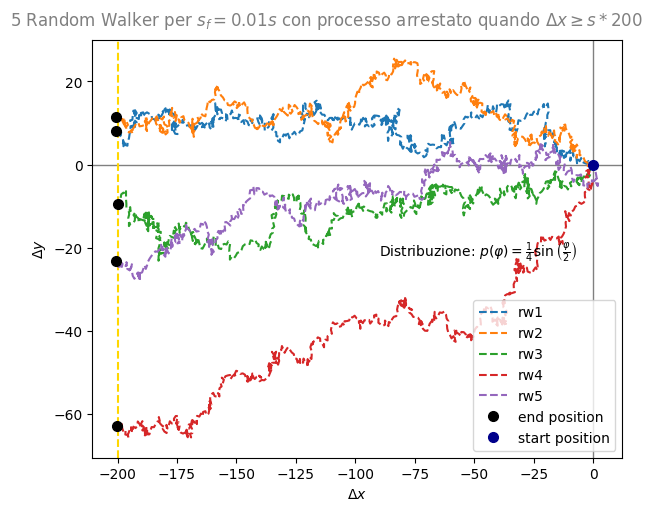

In [61]:
#grafico 5 random walker per sf=0.01 con processo arrestato quando n = s*200

fig3, ax=plt.subplots(figsize=(6,5), layout='constrained')

plt.suptitle(r'5 Random Walker per $s_f = 0.01 s$ con processo arrestato quando $ \Delta x \geq s*200$', color = 'grey')
count=1
mark=''
ax.axhline(0, color='grey', linewidth=1)
ax.axvline(0, color='grey', linewidth=1)
ax.axvline(-200, color='gold', linestyle='--')
for j,k in zip(s2x, d2x):
    if(count==5):
        mark='end position'
    ax.plot(rw_pa_dir2[0][j:k], rw_pa_dir2[1][j:k], '--', label='rw{:d}'.format(count))
    ax.plot(rw_pa_dir2[0][j:k][-1], rw_pa_dir2[1][j:k][-1],'o', markersize=7,label=mark, color='black')
    count +=1
ax.text(-90, -22,r'Distribuzione: $ p(\varphi)= \frac{1}{4} \sin \left( \frac{\varphi}{2} \right)$')
ax.plot(pstart[0], pstart[1], 'o', markersize=7, label='start position', color='darkblue')
ax.set_xlabel(r'$\Delta x$')
ax.set_ylabel(r'$\Delta y$')
ax.legend()